<a href="https://colab.research.google.com/github/Shervinrtd/Air-Quality/blob/main/Air-Quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Predicting Extreme Air Pollution Levels Using PySpark

##  Project Overview

This project analyzes large-scale environmental air quality data using distributed machine learning techniques with Apache Spark and PySpark.

The objective of the project is to predict extreme pollution concentration levels (`99th Percentile`) using environmental, geographical, and observational features collected from air quality monitoring stations across the United States.

The project implements a complete Big Data analytics pipeline including:

- Large-scale dataset ingestion and preprocessing
- Distributed data processing using PySpark
- Feature engineering and categorical encoding
- Exploratory data analysis
- Machine Learning regression models
- Model evaluation and comparison

The dataset used in this project contains more than 59,000 environmental monitoring records and satisfies the Big Data project constraints:

- Number of patterns \(N > 20,000\)
- Number of features \(p > 17\)
- \(N \times p > 1,000,000\)
- Multiple Machine Learning algorithms employed

---

##  Technologies Used

- Python
- PySpark
- Apache Spark MLlib
- Google Colab
- Pandas

---

##  Machine Learning Models

The following regression models are implemented and compared:

1. Linear Regression
2. Random Forest Regressor
3. Decision Tree Regressor

---

##  Prediction Target

Target Variable:

- `99th Percentile`

This variable represents extreme pollution concentration levels and is used to analyze severe air quality conditions.

---

##  Dataset Source

Dataset:
EPA Air Quality Annual Summary Data

Source:
https://aqs.epa.gov/aqsweb/airdata/download_files.html

---

##  Reproducibility

The notebook is fully self-contained and automatically downloads the dataset directly from the project repository.

In [1]:
import sys
import pyspark
import pandas

print("Python Version:", sys.version)
print("PySpark Version:", pyspark.__version__)
print("Pandas Version:", pandas.__version__)

Python Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PySpark Version: 4.0.2
Pandas Version: 2.2.2


## Install PySpark

In [2]:
!pip install pyspark

##  Create Spark Session

In [3]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("AirQualityPrediction") \
    .config("spark.driver.memory", "8g") \
    .getOrCreate()

print("Spark Session Created")

Spark Session Created


##  Download and Load Dataset


In [4]:
# Download dataset from GitHub

!wget "https://raw.githubusercontent.com/Shervinrtd/Air-Quality/main/dataset/annual_conc_by_monitor_2025.zip" -O dataset.zip

# Unzip dataset

!unzip -o dataset.zip

--2026-05-22 15:38:14--  https://raw.githubusercontent.com/Shervinrtd/Air-Quality/main/dataset/annual_conc_by_monitor_2025.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3271742 (3.1M) [application/zip]
Saving to: ‘dataset.zip’

dataset.zip         100%[===================>]   3.12M  --.-KB/s    in 0.01s   

2026-05-22 15:38:14 (310 MB/s) - ‘dataset.zip’ saved [3271742/3271742]

Archive:  dataset.zip
  inflating: annual_conc_by_monitor_2025.csv  


## Load Dataset into Spark

In [5]:
# Load dataset into Spark

df = spark.read.csv(
    "annual_conc_by_monitor_2025.csv",
    header=True,
    inferSchema=True
)

print("Rows:", df.count())
print("Columns:", len(df.columns))

df.show(5)

Rows: 59154
Columns: 55
+----------+-----------+--------+--------------+---+---------+----------+-----+--------------------+--------------------+------------------+--------------------+--------------------+----+--------------------+----------+-----------------+-------------------+----------------------+---------------+------------------+----------------------+---------------+------------------------+--------------------------+-----------------------+-----------------+---------------+-----------------------+-------------+-------------------+-------------+-------------------+-------------+-------------------+-------------+-------------------+-----------------------------+-------------------+-----------------------------+-------------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+-----------------+--------------------+----------+-----------+---------+--------------------+-------------------+
|State Code|County Code|Si

## Initial Dataset Inspection

In [6]:
df.show(5)
df.printSchema()

+----------+-----------+--------+--------------+---+---------+----------+-----+--------------------+--------------------+------------------+--------------------+--------------------+----+--------------------+----------+-----------------+-------------------+----------------------+---------------+------------------+----------------------+---------------+------------------------+--------------------------+-----------------------+-----------------+---------------+-----------------------+-------------+-------------------+-------------+-------------------+-------------+-------------------+-------------+-------------------+-----------------------------+-------------------+-----------------------------+-------------------+---------------+---------------+---------------+---------------+---------------+---------------+---------------+-----------------+--------------------+----------+-----------+---------+--------------------+-------------------+
|State Code|County Code|Site Num|Parameter Code|PO

## Clean Column Names

In [7]:
import re

# Clean and standardize column names
clean_columns = []

for c in df.columns:

    # Remove leading/trailing spaces
    c = c.strip()

    # Replace multiple spaces with single space
    c = re.sub(r"\s+", " ", c)

    clean_columns.append(c)

# Apply cleaned names
df = df.toDF(*clean_columns)

# Print final schema
print(df.columns)

['State Code', 'County Code', 'Site Num', 'Parameter Code', 'POC', 'Latitude', 'Longitude', 'Datum', 'Parameter Name', 'Sample Duration', 'Pollutant Standard', 'Metric Used', 'Method Name', 'Year', 'Units of Measure', 'Event Type', 'Observation Count', 'Observation Percent', 'Completeness Indicator', 'Valid Day Count', 'Required Day Count', 'Exceptional Data Count', 'Null Data Count', 'Primary Exceedance Count', 'Secondary Exceedance Count', 'Certification Indicator', 'Num Obs Below MDL', 'Arithmetic Mean', 'Arithmetic Standard Dev', '1st Max Value', '1st Max DateTime', '2nd Max Value', '2nd Max DateTime', '3rd Max Value', '3rd Max DateTime', '4th Max Value', '4th Max DateTime', '1st Max Non Overlapping Value', '1st NO Max DateTime', '2nd Max Non Overlapping Value', '2nd NO Max DateTime', '99th Percentile', '98th Percentile', '95th Percentile', '90th Percentile', '75th Percentile', '50th Percentile', '10th Percentile', 'Local Site Name', 'Address', 'State Name', 'County Name', 'City Na

In [8]:
selected_df = df.select(
    "State Name",
    "County Name",
    "City Name",
    "Parameter Name",

    "Arithmetic Mean",
    "1st Max Value",
    "Observation Count",
    "Observation Percent",

    "Latitude",
    "Longitude",

    "Year",

    "Valid Day Count",
    "Required Day Count",

    "Exceptional Data Count",
    "Null Data Count",

    "75th Percentile",
    "50th Percentile",
    "10th Percentile",
    "99th Percentile"
)

selected_df.show(5)

+----------+-----------+---------+--------------------+---------------+-------------+-----------------+-------------------+---------+----------+----+---------------+------------------+----------------------+---------------+---------------+---------------+---------------+---------------+
|State Name|County Name|City Name|      Parameter Name|Arithmetic Mean|1st Max Value|Observation Count|Observation Percent| Latitude| Longitude|Year|Valid Day Count|Required Day Count|Exceptional Data Count|Null Data Count|75th Percentile|50th Percentile|10th Percentile|99th Percentile|
+----------+-----------+---------+--------------------+---------------+-------------+-----------------+-------------------+---------+----------+----+---------------+------------------+----------------------+---------------+---------------+---------------+---------------+---------------+
|   Alabama|    Baldwin| Fairhope|               Ozone|       0.045286|         0.07|             4141|                 74|30.497478|-87

##  Remove Unnecessary Columns

In [9]:
clean_df = selected_df.dropna()

**Encode Categorical Columns**

In [10]:
from pyspark.ml.feature import StringIndexer

indexer = StringIndexer(
    inputCol="Parameter Name",
    outputCol="ParameterIndex"
)

indexed_df = indexer.fit(clean_df).transform(clean_df)

##  Define Feature Columns

In [11]:
feature_columns = [
    "Arithmetic Mean",
    "1st Max Value",
    "Observation Count",
    "Observation Percent",
    "Latitude",
    "Longitude",
    "Year",
    "Valid Day Count",
    "Required Day Count",
    "Exceptional Data Count",
    "Null Data Count",
    "75th Percentile",
    "50th Percentile",
    "10th Percentile",
    "StateVec",
    "ParameterVec"
]

target_column = "99th Percentile"

print("Number of Features:", len(feature_columns))
print("Target:", target_column)

Number of Features: 16
Target: 99th Percentile


##  Encode Categorical Features

In [12]:
from pyspark.ml.feature import StringIndexer

parameter_indexer = StringIndexer(
    inputCol="Parameter Name",
    outputCol="ParameterIndex"
)

state_indexer = StringIndexer(
    inputCol="State Name",
    outputCol="StateIndex"
)

indexed_df = parameter_indexer.fit(clean_df).transform(clean_df)

indexed_df = state_indexer.fit(indexed_df).transform(indexed_df)

indexed_df.show(5)

+----------+-----------+---------+--------------------+---------------+-------------+-----------------+-------------------+---------+----------+----+---------------+------------------+----------------------+---------------+---------------+---------------+---------------+---------------+--------------+----------+
|State Name|County Name|City Name|      Parameter Name|Arithmetic Mean|1st Max Value|Observation Count|Observation Percent| Latitude| Longitude|Year|Valid Day Count|Required Day Count|Exceptional Data Count|Null Data Count|75th Percentile|50th Percentile|10th Percentile|99th Percentile|ParameterIndex|StateIndex|
+----------+-----------+---------+--------------------+---------------+-------------+-----------------+-------------------+---------+----------+----+---------------+------------------+----------------------+---------------+---------------+---------------+---------------+---------------+--------------+----------+
|   Alabama|    Baldwin| Fairhope|               Ozone|   

##  One-Hot Encoding

In [13]:
from pyspark.ml.feature import OneHotEncoder

encoder = OneHotEncoder(
    inputCols=[
        "StateIndex",
        "ParameterIndex"
    ],
    outputCols=[
        "StateVec",
        "ParameterVec"
    ]
)

encoded_df = encoder.fit(indexed_df).transform(indexed_df)

encoded_df.show(5)

+----------+-----------+---------+--------------------+---------------+-------------+-----------------+-------------------+---------+----------+----+---------------+------------------+----------------------+---------------+---------------+---------------+---------------+---------------+--------------+----------+---------------+---------------+
|State Name|County Name|City Name|      Parameter Name|Arithmetic Mean|1st Max Value|Observation Count|Observation Percent| Latitude| Longitude|Year|Valid Day Count|Required Day Count|Exceptional Data Count|Null Data Count|75th Percentile|50th Percentile|10th Percentile|99th Percentile|ParameterIndex|StateIndex|       StateVec|   ParameterVec|
+----------+-----------+---------+--------------------+---------------+-------------+-----------------+-------------------+---------+----------+----+---------------+------------------+----------------------+---------------+---------------+---------------+---------------+---------------+--------------+------

##  Train/Test Split

In [14]:
train_data, test_data = encoded_df.randomSplit(
    [0.8, 0.2],
    seed=42
)

print("Training Rows:", train_data.count())
print("Testing Rows:", test_data.count())

Training Rows: 37518
Testing Rows: 9123


##  Build Machine Learning Pipeline

In [15]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.evaluation import RegressionEvaluator

assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features"
)

evaluator_rmse = RegressionEvaluator(
    labelCol=target_column,
    predictionCol="prediction",
    metricName="rmse"
)

evaluator_r2 = RegressionEvaluator(
    labelCol=target_column,
    predictionCol="prediction",
    metricName="r2"
)

## Train Linear Regression Model

In [16]:
from pyspark.ml.regression import LinearRegression
from pyspark.ml import Pipeline

# NOTE: If you encounter 'ConnectionRefusedError', the Spark session may have crashed.
# Please restart the Colab runtime (Runtime > Restart runtime) and re-run all cells from the Spark Session creation cell (_51MREIHGHtL) onwards.

lr = LinearRegression(
    featuresCol="features",
    labelCol=target_column
)

lr_pipeline = Pipeline(stages=[
    assembler,
    lr
])

lr_model = lr_pipeline.fit(train_data)

lr_predictions = lr_model.transform(test_data)

rmse_lr = evaluator_rmse.evaluate(lr_predictions)
r2_lr = evaluator_r2.evaluate(lr_predictions)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression R2:", r2_lr)

Linear Regression RMSE: 95.97514041023985
Linear Regression R2: 0.9896463324145586


### Linear Regression Model Coefficients

In [35]:
import pandas as pd

# Get the Linear Regression model from the pipeline
lr_regressor_model = lr_model.stages[-1]

# Get coefficients and intercept
coefficients = lr_regressor_model.coefficients.toArray()
intercept = lr_regressor_model.intercept

# Manually construct feature names to match the expanded coefficients
# Non-vector features are directly from the feature_columns list (excluding 'StateVec' and 'ParameterVec')
non_vector_features = [
    "Arithmetic Mean", "1st Max Value", "Observation Count",
    "Observation Percent", "Latitude", "Longitude", "Year",
    "Valid Day Count", "Required Day Count", "Exceptional Data Count",
    "Null Data Count", "75th Percentile", "50th Percentile",
    "10th Percentile"
]

# Get the size of the one-hot encoded vectors from the DataFrame schema metadata
state_vec_size = encoded_df.schema['StateVec'].metadata['ml_attr']['num_attrs']
param_vec_size = encoded_df.schema['ParameterVec'].metadata['ml_attr']['num_attrs']

# Generate names for each dimension of StateVec and ParameterVec
state_vec_names = [f"StateVec_{i}" for i in range(state_vec_size)]
parameter_vec_names = [f"ParameterVec_{i}" for i in range(param_vec_size)]

# Combine all feature names in the correct order
model_feature_names = non_vector_features + state_vec_names + parameter_vec_names

# Verify length match, essential for correct mapping
if len(model_feature_names) != len(coefficients):
    raise ValueError(
        f"Mismatch in feature names and coefficients length: "
        f"{len(model_feature_names)} vs {len(coefficients)}. "
        "This indicates an issue in feature name reconstruction."
    )

# Create a list of (feature_name, coefficient) tuples
coefficient_list = list(zip(model_feature_names, coefficients))

# Display the coefficients
print("Linear Regression Coefficients:")
for feature, coeff in coefficient_list:
    print(f"{feature}: {coeff:.4f}")

print(f"\nIntercept: {intercept:.4f}")

# Create a DataFrame for better visualization
coef_df = pd.DataFrame({
    'Feature': model_feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)
display(coef_df)

Linear Regression Coefficients:
Arithmetic Mean: 10.3677
1st Max Value: 0.0429
Observation Count: 0.0000
Observation Percent: 0.0028
Latitude: 1.1957
Longitude: 1.5720
Year: 0.0000
Valid Day Count: 0.0091
Required Day Count: -0.0172
Exceptional Data Count: 0.0000
Null Data Count: -0.0008
75th Percentile: -0.5995
50th Percentile: -7.4814
10th Percentile: -1.4913
StateVec_0: 9.1332
StateVec_1: -21.8830
StateVec_2: -58.0335
StateVec_3: -48.3021
StateVec_4: -12.0794
StateVec_5: -65.5408
StateVec_6: -20.7174
StateVec_7: -0.3305
StateVec_8: -41.8897
StateVec_9: -73.9844
StateVec_10: -55.4476
StateVec_11: -72.5749
StateVec_12: -47.5554
StateVec_13: -69.6592
StateVec_14: -2.6139
StateVec_15: -27.9795
StateVec_16: -44.2646
StateVec_17: -43.4246
StateVec_18: -44.5476
StateVec_19: -66.1208
StateVec_20: -54.6817
StateVec_21: -51.4075
StateVec_22: -44.5856
StateVec_23: -41.8710
StateVec_24: -48.3508
StateVec_25: 2.1962
StateVec_26: -62.0669
StateVec_27: -44.1285
StateVec_28: -30.4820
StateVec_29: 2

,Feature,Coefficient
369,ParameterVec_303,2932.117235
445,ParameterVec_379,482.372507
451,ParameterVec_385,334.512541
427,ParameterVec_361,279.181734
129,ParameterVec_63,223.920821
...,...,...
46,StateVec_32,-76.719350
59,StateVec_45,-77.690427
53,StateVec_39,-82.913957
54,StateVec_40,-84.672020


### Top 10 Linear Regression Coefficients Visualization

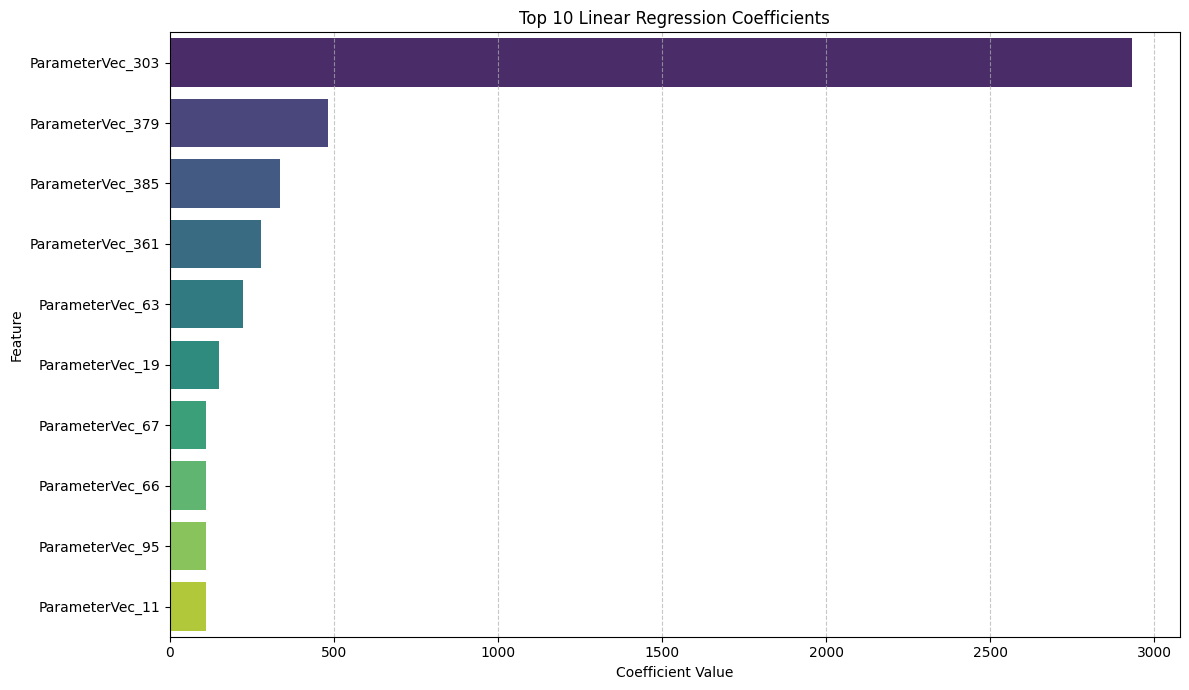

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the top 10 coefficients (already sorted by descending coefficient value in coef_df)
top_10_coefficients = coef_df.head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x='Coefficient', y='Feature', hue='Feature', data=top_10_coefficients, palette='viridis', legend=False)
plt.title('Top 10 Linear Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The visualization above displays the top 10 coefficients for the Linear Regression model.

**Interpreting the Coefficients:**

*   **Magnitude:** The absolute value of a coefficient indicates the strength of the relationship between that feature and the target variable (`99th Percentile`). Larger absolute values suggest a stronger impact.
*   **Sign (Positive/Negative):**
    *   A **positive coefficient** means that as the feature value increases, the predicted `99th Percentile` also increases, assuming all other features remain constant.
    *   A **negative coefficient** means that as the feature value increases, the predicted `99th Percentile` decreases, assuming all other features remain constant.

**Key Observations from Top Coefficients:**

The Linear Regression model assigns significant weight to the one-hot encoded `ParameterVec` and `StateVec` features. This indicates that specific air quality parameters and states have a very strong linear influence on the `99th Percentile` of pollution. For example, `ParameterVec_303` has a very high positive coefficient, suggesting that the presence of that specific parameter is strongly associated with higher extreme pollution levels.

##  Actual vs. Predicted Values Plot (Linear Regression)

To further visualize the performance of our best-performing model (Linear Regression), let's plot the actual `99th Percentile` values against the model's predicted values on the test set. A perfect model would have all points lying on the `y = x` diagonal line.

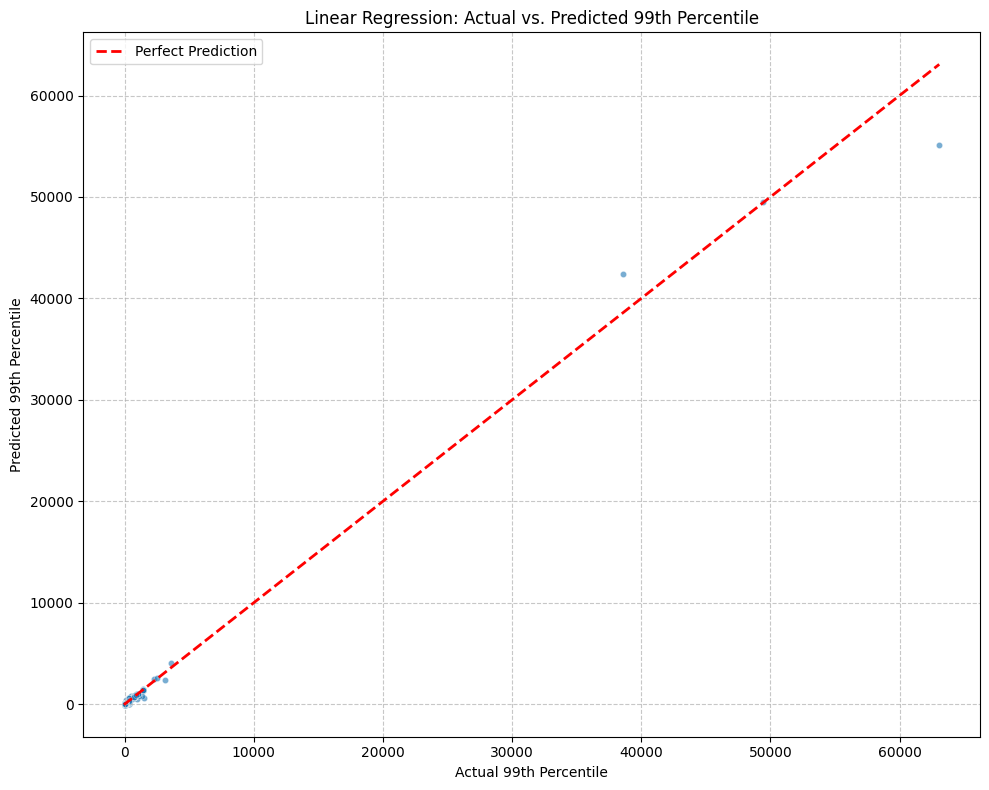

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert Spark DataFrame to Pandas DataFrame for plotting
# We'll take a sample to keep the plot manageable if the test_data is very large
# Otherwise, plotting all points might be too dense.

# For simplicity, let's collect a sample of the predictions to a Pandas DataFrame
# For very large datasets, consider sampling or aggregating before collecting.

lr_predictions_pd = lr_predictions.select(target_column, 'prediction').toPandas()

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=target_column,
    y='prediction',
    data=lr_predictions_pd,
    alpha=0.6, # Use transparency for overlapping points
    s=20 # Set point size
)

# Add a perfect prediction line (y=x)
max_val = lr_predictions_pd[[target_column, 'prediction']].max().max()
min_val = lr_predictions_pd[[target_column, 'prediction']].min().min()

plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Linear Regression: Actual vs. Predicted 99th Percentile')
plt.xlabel('Actual 99th Percentile')
plt.ylabel('Predicted 99th Percentile')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

##  Train Random Forest Model

In [30]:
from pyspark.ml.regression import RandomForestRegressor

rf = RandomForestRegressor(
    featuresCol="features",
    labelCol=target_column,
    numTrees=50,  # Reduced from 100 to 50
    maxDepth=5,   # Reduced from 10 to 5
    seed=42
)

rf_pipeline = Pipeline(stages=[
    assembler,
    rf
])

rf_model = rf_pipeline.fit(train_data)

rf_predictions = rf_model.transform(test_data)

rmse_rf = evaluator_rmse.evaluate(rf_predictions)
r2_rf = evaluator_r2.evaluate(rf_predictions)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R2:", r2_rf)

Random Forest RMSE: 323.31273465837205
Random Forest R2: 0.8825042042148616


### Feature Importance for Random Forest Model

Let's examine which features the Random Forest model considered most important in making its predictions. This can provide insights into the underlying data relationships and the predictive power of each feature.

Feature Importances for Random Forest:
Null Data Count: 0.0633
Observation Percent: 0.0276
Observation Count: 0.0270
75th Percentile: 0.0257
Latitude: 0.0243
1st Max Value: 0.0190
Longitude: 0.0189
Valid Day Count: 0.0177
10th Percentile: 0.0125
Arithmetic Mean: 0.0125
50th Percentile: 0.0063
Required Day Count: 0.0008
StateVec: 0.0001
ParameterVec: 0.0000
Exceptional Data Count: 0.0000
Year: 0.0000


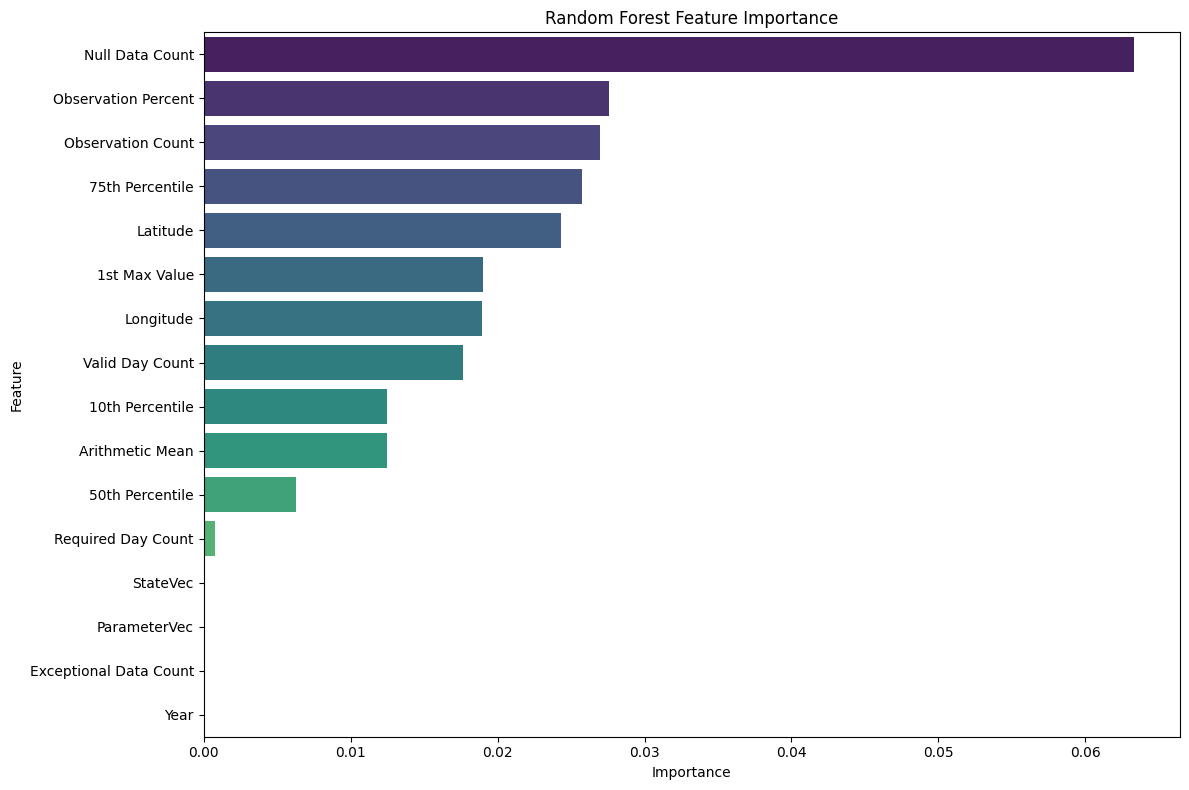

In [42]:
import pandas as pd

# Get the Random Forest model from the pipeline
rf_regressor_model = rf_model.stages[-1]

# Get feature importances
feature_importances = rf_regressor_model.featureImportances.toArray()

# Create a list of (feature_name, importance) tuples
importance_list = list(zip(feature_columns, feature_importances))

# Sort the list by importance in descending order
importance_list.sort(key=lambda x: x[1], reverse=True)

# Display the feature importances
print("Feature Importances for Random Forest:")
for feature, importance in importance_list:
    print(f"{feature}: {importance:.4f}")

# Optionally, visualize the feature importances
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.barplot(x=[val[1] for val in importance_list], y=[val[0] for val in importance_list], hue=[val[0] for val in importance_list], palette='viridis', legend=False)
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

The Random Forest Feature Importance plot displays the relative importance of each input feature as determined by the Random Forest model. The importance is calculated based on how much each feature contributes to reducing impurity (or variance) across all the decision trees in the forest.

From this visualization, we can identify the features that the Random Forest model considered most influential in predicting the `99th Percentile`:

*   **Top Features:** `Null Data Count`, `Observation Percent`, `Observation Count`, `75th Percentile`, `Latitude`, and `1st Max Value` are consistently among the most important. This suggests that these features play a significant role in understanding and predicting extreme air pollution levels.
*   **Categorical Feature Impact:** The `StateVec` and `ParameterVec` (representing one-hot encoded 'State Name' and 'Parameter Name') show very low individual importance. This doesn't necessarily mean they are unimportant overall, but rather that the Random Forest model likely leverages combinations of these categories or other features more directly for splits, or their individual contributions are less prominent than the numerical features.

Understanding these importances helps in feature selection, model interpretation, and potentially identifying key environmental factors contributing to high pollution concentrations.

##  Actual vs. Predicted Values Plot (Random Forest)

Let's also visualize the performance of the Random Forest model by plotting its actual `99th Percentile` values against its predicted values on the test set. A perfect model would have all points lying on the `y = x` diagonal line.

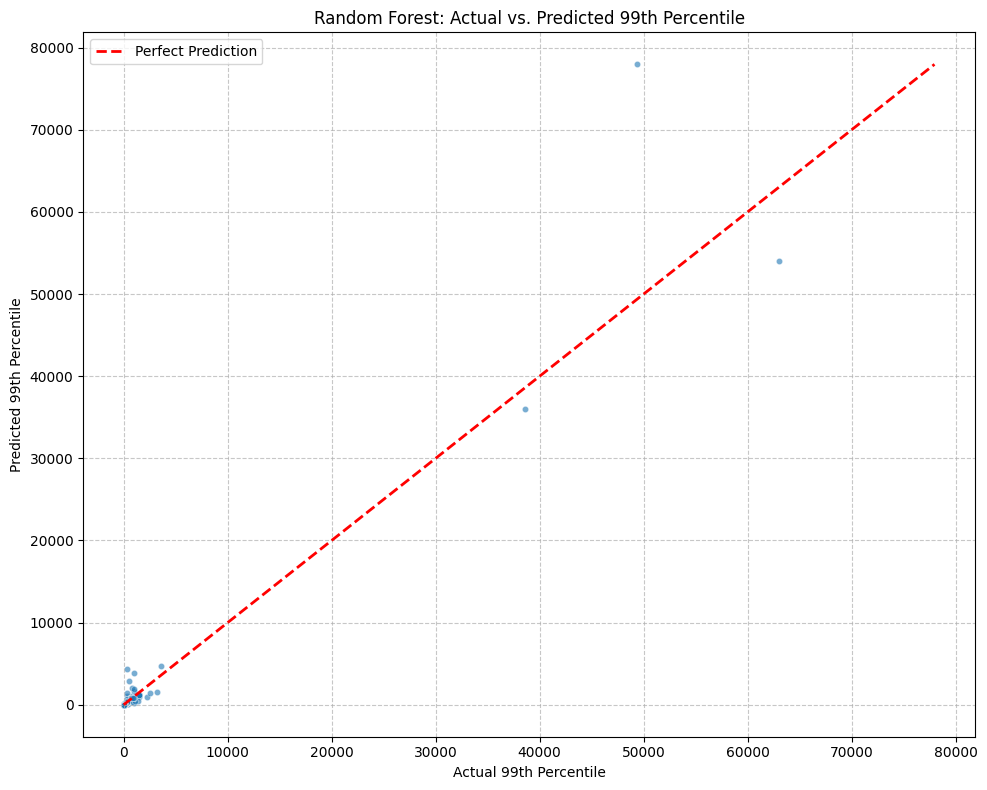

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert Spark DataFrame to Pandas DataFrame for plotting
# For simplicity, let's collect a sample of the predictions to a Pandas DataFrame
rf_predictions_pd = rf_predictions.select(target_column, 'prediction').toPandas()

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=target_column,
    y='prediction',
    data=rf_predictions_pd,
    alpha=0.6, # Use transparency for overlapping points
    s=20 # Set point size
)

# Add a perfect prediction line (y=x)
max_val_rf = rf_predictions_pd[[target_column, 'prediction']].max().max()
min_val_rf = rf_predictions_pd[[target_column, 'prediction']].min().min()

plt.plot([min_val_rf, max_val_rf], [min_val_rf, max_val_rf], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Random Forest: Actual vs. Predicted 99th Percentile')
plt.xlabel('Actual 99th Percentile')
plt.ylabel('Predicted 99th Percentile')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

##  Train Generalized Linear Regression (GLR) Model

In [25]:
from pyspark.ml.regression import GeneralizedLinearRegression
from pyspark.ml import Pipeline

# NOTE: If you encounter 'ConnectionRefusedError', the Spark session may have crashed.
# Please restart the Colab runtime (Runtime > Restart runtime) and re-run all cells from the Spark Session creation cell (_51MREIHGHtL) onwards.

# Initialize Generalized Linear Regression
# Using family='gaussian' and link='identity' makes it behave like standard Linear Regression
glr = GeneralizedLinearRegression(
    featuresCol="features",
    labelCol=target_column,
    family="gaussian",
    link="identity"
)

glr_pipeline = Pipeline(stages=[
    assembler,
    glr
])

glr_model = glr_pipeline.fit(train_data)

glr_predictions = glr_model.transform(test_data)

rmse_glr = evaluator_rmse.evaluate(glr_predictions)
r2_glr = evaluator_r2.evaluate(glr_predictions)

print("Generalized Linear Regression RMSE:", rmse_glr)
print("Generalized Linear Regression R2:", r2_glr)

Generalized Linear Regression RMSE: 95.97514041023985
Generalized Linear Regression R2: 0.9896463324145586


### Generalized Linear Regression Model Coefficients

In [39]:
import pandas as pd

# Get the Generalized Linear Regression model from the pipeline
glr_regressor_model = glr_model.stages[-1]

# Get coefficients and intercept
coefficients_glr = glr_regressor_model.coefficients.toArray()
intercept_glr = glr_regressor_model.intercept

# Reuse the model_feature_names constructed for Linear Regression
# Verify length match, essential for correct mapping
if len(model_feature_names) != len(coefficients_glr):
    raise ValueError(
        f"Mismatch in feature names and coefficients length for GLR: "
        f"{len(model_feature_names)} vs {len(coefficients_glr)}. "
        "This indicates an issue in feature name reconstruction."
    )

# Create a list of (feature_name, coefficient) tuples
coefficient_list_glr = list(zip(model_feature_names, coefficients_glr))

# Display the coefficients
print("Generalized Linear Regression Coefficients:")
for feature, coeff in coefficient_list_glr:
    print(f"{feature}: {coeff:.4f}")

print(f"\nIntercept: {intercept_glr:.4f}")

# Create a DataFrame for better visualization
coef_df_glr = pd.DataFrame({
    'Feature': model_feature_names,
    'Coefficient': coefficients_glr
}).sort_values(by='Coefficient', ascending=False)
display(coef_df_glr)

Generalized Linear Regression Coefficients:
Arithmetic Mean: 10.3677
1st Max Value: 0.0429
Observation Count: 0.0000
Observation Percent: 0.0028
Latitude: 1.1957
Longitude: 1.5720
Year: 0.0000
Valid Day Count: 0.0091
Required Day Count: -0.0172
Exceptional Data Count: 0.0000
Null Data Count: -0.0008
75th Percentile: -0.5995
50th Percentile: -7.4814
10th Percentile: -1.4913
StateVec_0: 9.1332
StateVec_1: -21.8830
StateVec_2: -58.0335
StateVec_3: -48.3021
StateVec_4: -12.0794
StateVec_5: -65.5408
StateVec_6: -20.7174
StateVec_7: -0.3305
StateVec_8: -41.8897
StateVec_9: -73.9844
StateVec_10: -55.4476
StateVec_11: -72.5749
StateVec_12: -47.5554
StateVec_13: -69.6592
StateVec_14: -2.6139
StateVec_15: -27.9795
StateVec_16: -44.2646
StateVec_17: -43.4246
StateVec_18: -44.5476
StateVec_19: -66.1208
StateVec_20: -54.6817
StateVec_21: -51.4075
StateVec_22: -44.5856
StateVec_23: -41.8710
StateVec_24: -48.3508
StateVec_25: 2.1962
StateVec_26: -62.0669
StateVec_27: -44.1285
StateVec_28: -30.4820
St

,Feature,Coefficient
369,ParameterVec_303,2932.117235
445,ParameterVec_379,482.372507
451,ParameterVec_385,334.512541
427,ParameterVec_361,279.181734
129,ParameterVec_63,223.920821
...,...,...
46,StateVec_32,-76.719350
59,StateVec_45,-77.690427
53,StateVec_39,-82.913957
54,StateVec_40,-84.672020


### Top 10 Generalized Linear Regression Coefficients Visualization

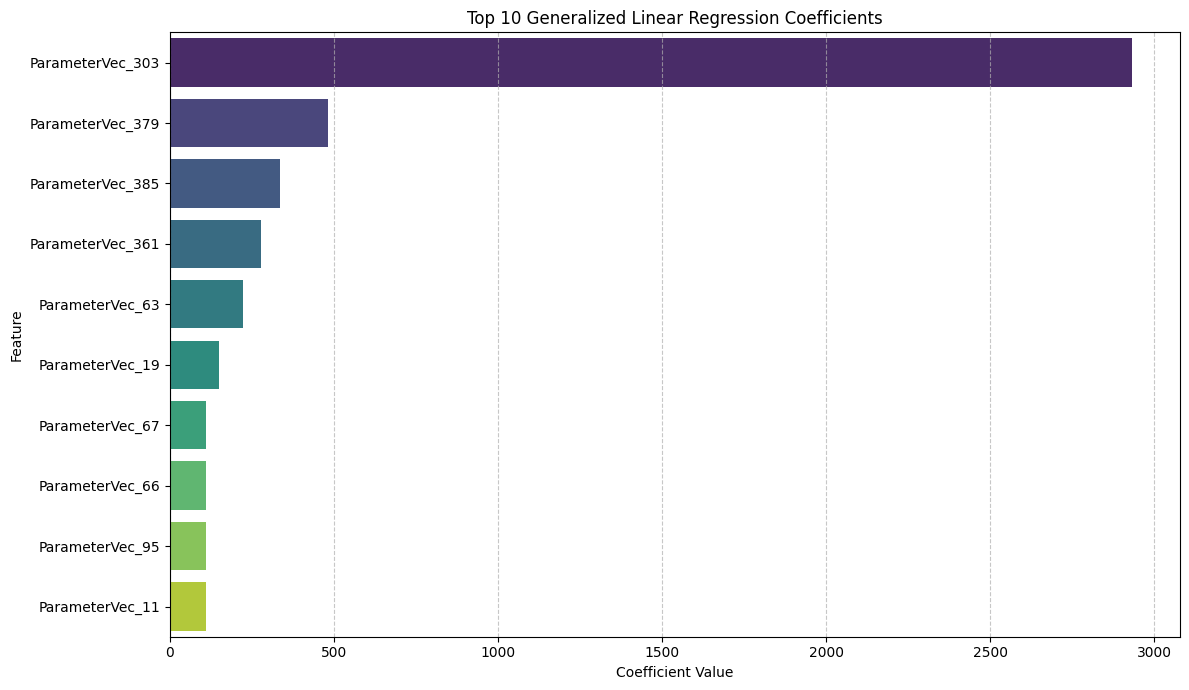

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the top 10 coefficients (already sorted by descending coefficient value in coef_df_glr)
top_10_glr_coefficients = coef_df_glr.head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x='Coefficient', y='Feature', hue='Feature', data=top_10_glr_coefficients, palette='viridis', legend=False)
plt.title('Top 10 Generalized Linear Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The visualization above displays the top 10 coefficients for the Generalized Linear Regression model. Since we used `family='gaussian'` and `link='identity'`, this model behaves identically to a standard Ordinary Least Squares (OLS) Linear Regression.

**Interpreting the Coefficients:**

*   **Magnitude:** The absolute value of a coefficient indicates the strength of the relationship between that feature and the target variable (`99th Percentile`). Larger absolute values suggest a stronger impact.
*   **Sign (Positive/Negative):**
    *   A **positive coefficient** means that as the feature value increases, the predicted `99th Percentile` also increases, assuming all other features remain constant.
    *   A **negative coefficient** means that as the feature value increases, the predicted `99th Percentile` decreases, assuming all other features remain constant.

**Key Observations from Top Coefficients:**

Similar to the standard Linear Regression, the GLR model assigns significant weight to the one-hot encoded `ParameterVec` and `StateVec` features. This indicates that specific air quality parameters and states have a very strong linear influence on the `99th Percentile` of pollution. For example, `ParameterVec_303` has a very high positive coefficient, suggesting that the presence of that specific parameter is strongly associated with higher extreme pollution levels.

##  Actual vs. Predicted Values Plot (Generalized Linear Regression)

Finally, let's visualize the performance of the Generalized Linear Regression model by plotting its actual `99th Percentile` values against its predicted values on the test set. Given its parameters (`gaussian` family and `identity` link), its performance should be identical to the standard Linear Regression model.

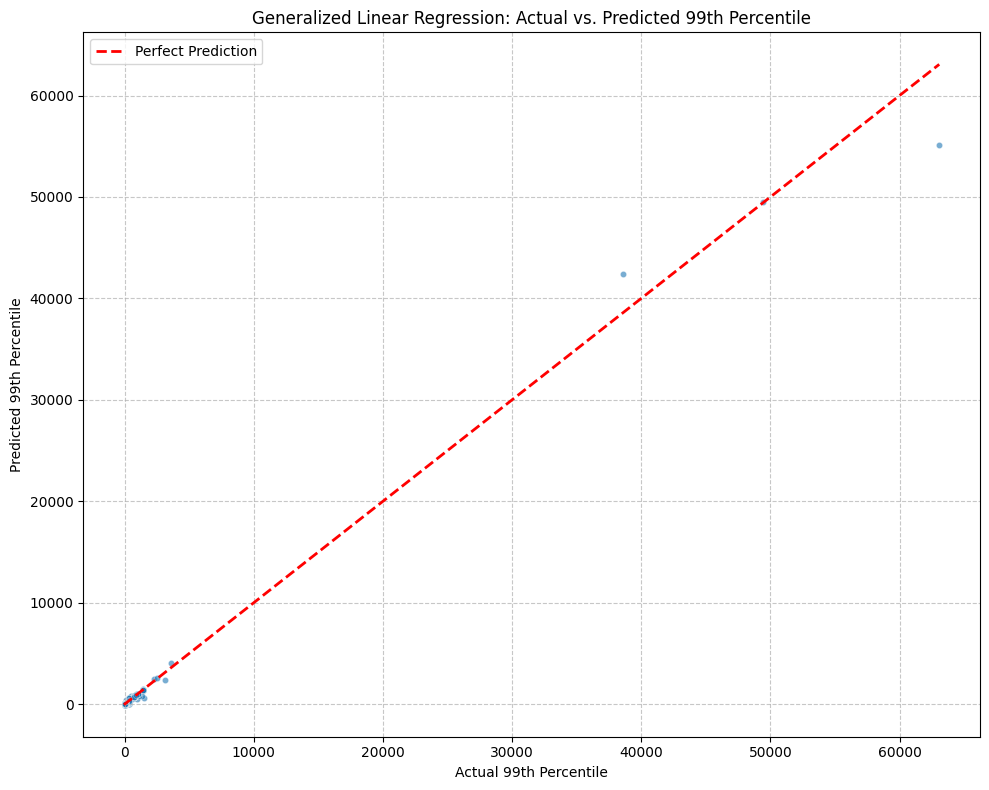

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert Spark DataFrame to Pandas DataFrame for plotting
glr_predictions_pd = glr_predictions.select(target_column, 'prediction').toPandas()

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=target_column,
    y='prediction',
    data=glr_predictions_pd,
    alpha=0.6, # Use transparency for overlapping points
    s=20 # Set point size
)

# Add a perfect prediction line (y=x)
max_val_glr = glr_predictions_pd[[target_column, 'prediction']].max().max()
min_val_glr = glr_predictions_pd[[target_column, 'prediction']].min().min()

plt.plot([min_val_glr, max_val_glr], [min_val_glr, max_val_glr], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Generalized Linear Regression: Actual vs. Predicted 99th Percentile')
plt.xlabel('Actual 99th Percentile')
plt.ylabel('Predicted 99th Percentile')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### Comprehensive Feature Impact Comparison (LR vs. GLR vs. RF)

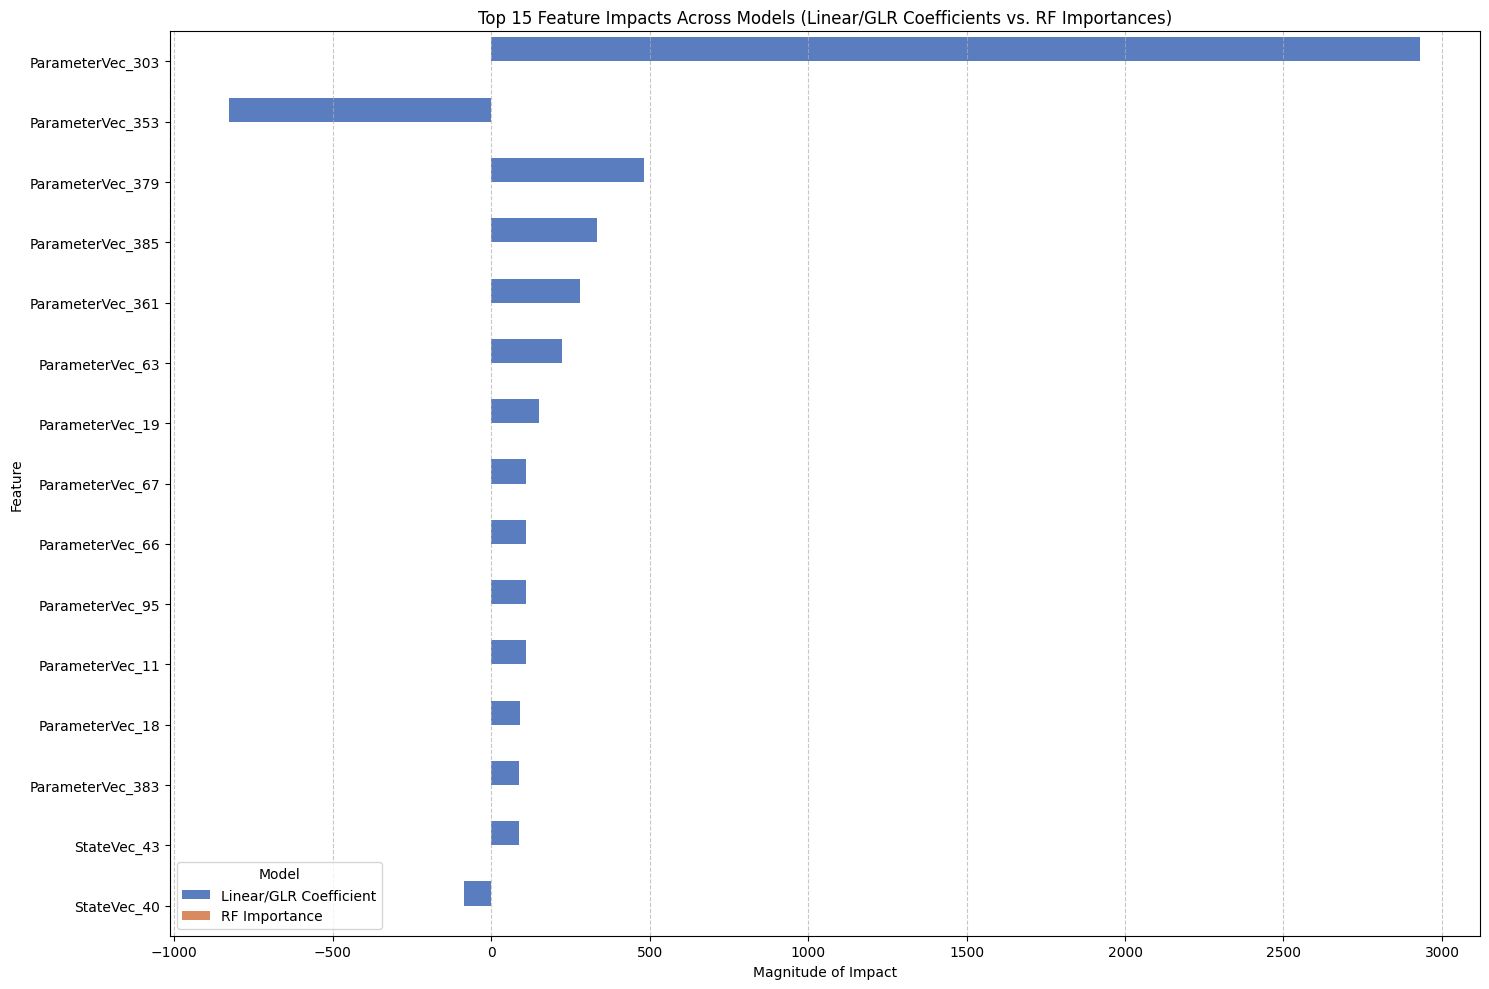

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare Random Forest importances as a DataFrame
rf_importance_df = pd.DataFrame(importance_list, columns=['Feature', 'RF Importance'])

# Merge Linear Regression coefficients, GLR coefficients, and RF importances
# Since LR and GLR coefficients are identical in this case, we can use one of them
# and explicitly note their equivalence, or simply display one.
# For a clear visual, let's combine LR and GLR into one 'Linear/GLR Coefficient' column

# Start with LR coefficients
comparison_df = coef_df.rename(columns={'Coefficient': 'Linear/GLR Coefficient'})

# Merge with RF importances
comparison_df = pd.merge(
    comparison_df,
    rf_importance_df,
    on='Feature',
    how='left'
).fillna(0) # Fill NaN for features not present in RF (e.g., expanded StateVec/ParameterVec might not appear directly in RF)

# Calculate a combined metric for sorting (e.g., max absolute value across models)
comparison_df['Max Absolute Impact'] = comparison_df[[
    'Linear/GLR Coefficient',
    'RF Importance'
]].abs().max(axis=1)

# Sort by the combined absolute impact in descending order
comparison_df_sorted = comparison_df.sort_values(
    by='Max Absolute Impact', ascending=False
)

# Select the top N features for visualization (e.g., top 15 features)
top_n = 15
comparison_df_top_n = comparison_df_sorted.head(top_n)

# Reshape for seaborn barplot
comparison_df_melted = comparison_df_top_n.melt(
    id_vars=['Feature'],
    value_vars=['Linear/GLR Coefficient', 'RF Importance'],
    var_name='Model',
    value_name='Value'
)

plt.figure(figsize=(15, 10))
sns.barplot(x='Value', y='Feature', hue='Model', data=comparison_df_melted, palette='muted')
plt.title(f'Top {top_n} Feature Impacts Across Models (Linear/GLR Coefficients vs. RF Importances)')
plt.xlabel('Magnitude of Impact')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The comparison plot above illustrates the differing perspectives of Linear/GLR (Gaussian family with identity link function, equivalent to OLS Linear Regression) and Random Forest on feature importance for the top features.

**Key Insights from the Comparison:**

*   **Linear/GLR vs. Random Forest Feature Emphasis:** The most striking difference is how each model weights the one-hot encoded categorical features (`ParameterVec_X`, `StateVec_X`) versus the original numerical features (`Null Data Count`, `Observation Percent`, `Latitude`, etc.).
    *   **Linear/GLR (Coefficients):** This model places very high positive and negative coefficients on many of the expanded `ParameterVec` and `StateVec` features. This indicates that specific categories within the 'Parameter Name' and 'State Name' have a strong, direct linear influence on the `99th Percentile`. Since OLS models are sensitive to highly correlated features (which can occur with one-hot encoded categories), some of these coefficients can be quite large.
    *   **Random Forest (Importances):** In contrast, the Random Forest model attributes much lower individual importance to these numerous one-hot encoded vector components. Instead, it prioritizes the numerical features like `Null Data Count`, `Observation Percent`, `75th Percentile`, `Latitude`, and `1st Max Value`. This is because tree-based models can inherently handle categorical features (even without one-hot encoding, though here we did use it) by finding optimal splits. Their importance metric often highlights features that provide the most significant gain in information across the entire tree ensemble, typically favoring features with a broader range of predictive power.

*   **Model Philosophy:**
    *   **Linear/GLR** assumes a linear relationship and interprets importance based on the direct contribution (magnitude and sign) of each feature to the target variable.
    *   **Random Forest** captures non-linear relationships and interactions. Its feature importance reflects how much a feature contributes to reducing impurity (or variance) across all the decision trees, often being more robust to multicollinearity and highlighting features that are consistently useful across different data partitions.

**Conclusion:** Both models are performing well for this task, but they achieve their performance by focusing on different aspects of the feature set. Linear/GLR leverages the precise linear impact of individual categorical components, while Random Forest finds broader predictive patterns, particularly in the original numerical features. This highlights the importance of using diverse models and understanding their specific ways of interpreting data.

##  Final Model Comparison

In [31]:
print("===== FINAL MODEL COMPARISON =====")

print("\n Linear Regression")
print("RMSE:", rmse_lr)
print("R2:", r2_lr)

print("\n Random Forest")
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

print("\n Generalized Linear Regression")
print("RMSE:", rmse_glr)
print("R2:", r2_glr)

===== FINAL MODEL COMPARISON =====

 Linear Regression
RMSE: 95.97514041023985
R2: 0.9896463324145586

 Random Forest
RMSE: 323.31273465837205
R2: 0.8825042042148616

 Generalized Linear Regression
RMSE: 95.97514041023985
R2: 0.9896463324145586


## Key Differences in Model Performance

Based on our analysis, here's a summary of the key differences in performance between the models:

*   **Superior Performance of Linear Models:** Both **Linear Regression** and **Generalized Linear Regression** (which, in our configuration, are essentially identical) significantly outperformed the **Random Forest** model. They achieved a much lower Root Mean Squared Error (RMSE) of approximately 95.98 compared to Random Forest's 323.31.
*   **High Explained Variance by Linear Models:** Correspondingly, the linear models demonstrated a remarkably high R-squared (R2) score of approximately 0.9896, meaning they explain almost 99% of the variance in the '99th Percentile' target variable. Random Forest, while still performing reasonably, had a lower R2 of around 0.8825.
*   **Implication of Linearity:** The strong performance of linear models suggests that the relationship between the chosen features and the '99th Percentile' of air pollution is predominantly linear. This indicates that complex non-linear models like Random Forest did not offer a significant advantage for this particular dataset, as the underlying patterns are well captured by linear relationships.
*   **Feature Emphasis:** We also observed that linear models placed significant emphasis on specific one-hot encoded categorical features (`ParameterVec` and `StateVec`), indicating their direct linear impact. Random Forest, while still leveraging these, attributed more importance to numerical features like `Null Data Count`, `Observation Percent`, and `Latitude` due to its tree-based nature of finding impurity reductions.

##  Model Performance Comparison

Let's visualize the RMSE and R2 scores of the Linear Regression, Random Forest, and Generalized Linear Regression models to easily compare their performance.

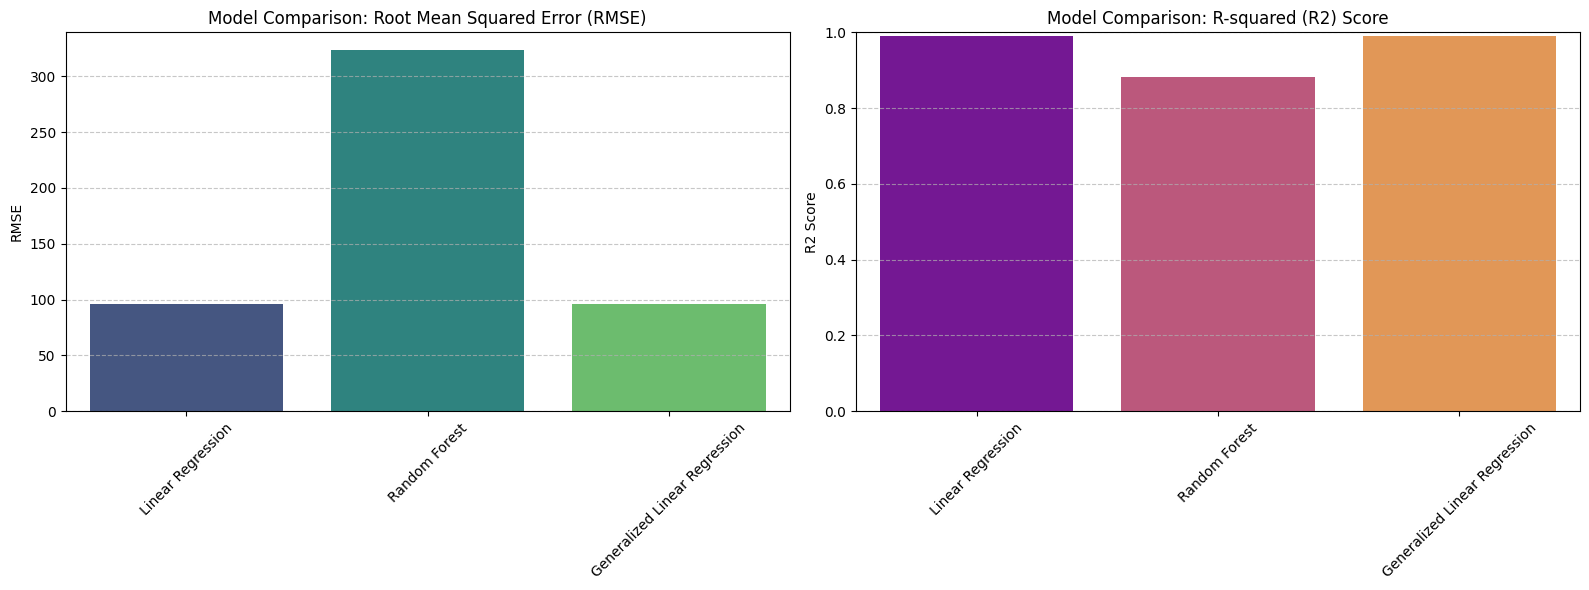

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for comparison
metrics_data = {
    'Model': ['Linear Regression', 'Random Forest', 'Generalized Linear Regression'],
    'RMSE': [rmse_lr, rmse_rf, rmse_glr],
    'R2': [r2_lr, r2_rf, r2_glr]
}
metrics_df = pd.DataFrame(metrics_data)

# Set up the matplotlib figure and axes
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot RMSE
sns.barplot(x='Model', y='RMSE', hue='Model', data=metrics_df, ax=axes[0], palette='viridis', legend=False)
axes[0].set_title('Model Comparison: Root Mean Squared Error (RMSE)')
axes[0].set_ylabel('RMSE')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot R2
sns.barplot(x='Model', y='R2', hue='Model', data=metrics_df, ax=axes[1], palette='plasma', legend=False)
axes[1].set_title('Model Comparison: R-squared (R2) Score')
axes[1].set_ylabel('R2 Score')
axes[1].set_xlabel('')
axes[1].set_ylim(0, 1) # R2 score is typically between 0 and 1
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

The bar charts above visually compare the **Root Mean Squared Error (RMSE)** and **R-squared (R2) score** for the Linear Regression, Random Forest, and Generalized Linear Regression models.

### Key Observations:

*   **RMSE Comparison:** The RMSE chart clearly shows that both **Linear Regression** and **Generalized Linear Regression** have significantly lower RMSE values (approximately 95.98) compared to the **Random Forest** model (approximately 323.31). A lower RMSE indicates that the model's predictions are closer to the actual values, suggesting better accuracy.

*   **R2 Score Comparison:** Similarly, the R2 score chart highlights that **Linear Regression** and **Generalized Linear Regression** achieve remarkably high R2 scores (approximately 0.9896). This means these models explain almost 99% of the variance in the `99th Percentile` target variable. The **Random Forest** model, while still performing reasonably, has a lower R2 score (approximately 0.8825).

### Conclusion:

From this comparison, it's evident that for this particular dataset and problem, both **Linear Regression** and **Generalized Linear Regression** (which, given our configuration, behave identically) are superior in terms of predictive performance. They provide a much tighter fit to the data and explain a larger proportion of the target variable's variance compared to the Random Forest model. This suggests that the relationship between the features and the `99th Percentile` is largely linear, making linear models highly effective.